In [3]:
import numpy as np
import pandas as pd 
import os

In [4]:
pip install timm

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm
from PIL import Image

In [6]:
# Directories for real and manipulated videos
real_videos_dir = "/kaggle/input/deep-fake-detection-dfd-entire-original-dataset/DFD_original sequences"
manipulated_videos_dir = "/kaggle/input/deep-fake-detection-dfd-entire-original-dataset/DFD_manipulated_sequences/DFD_manipulated_sequences"

# Output directories for extracted frames
output_real_dir = "/kaggle/working/frames/real"
output_manipulated_dir = "/kaggle/working/frames/manipulated"

In [7]:
# Ensure output directories exist
os.makedirs(output_real_dir, exist_ok=True)
os.makedirs(output_manipulated_dir, exist_ok=True)

In [8]:
def extract_frames_from_videos(videos_dir, output_dir, label, max_videos=100):
    video_files = [f for f in os.listdir(videos_dir) if f.endswith(('.mp4', '.avi', '.mov', '.mkv'))]
    video_files = video_files[:max_videos]  # Limit to max_videos

    for video_file in video_files:
        video_path = os.path.join(videos_dir, video_file)
        cap = cv2.VideoCapture(video_path)
        frame_count = 0
        success, image = cap.read()

        while success:
            if frame_count % int(cap.get(cv2.CAP_PROP_FPS)) == 0:
                frame_filename = f"{label}_{video_file}_frame{frame_count // int(cap.get(cv2.CAP_PROP_FPS))}.jpg"
                frame_path = os.path.join(output_dir, frame_filename)
                cv2.imwrite(frame_path, image)
            success, image = cap.read()
            frame_count += 1

        cap.release()

In [9]:
# Extract frames from 100 real and 100 manipulated videos
extract_frames_from_videos(real_videos_dir, output_real_dir, "real", max_videos=100)
extract_frames_from_videos(manipulated_videos_dir, output_manipulated_dir, "manipulated", max_videos=100)
print("Frame extraction completed.")

Frame extraction completed.


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define image transformations with advanced augmentations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [33]:
# Load the dataset
dataset_dir = "/kaggle/working/frames"  # Directory where frames are saved
dataset = datasets.ImageFolder(root=dataset_dir, transform=transform)

# Split dataset into training and validation sets
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size  # Ensures full coverage

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

In [19]:
from transformers import Swinv2Config, Swinv2Model

In [16]:
import timm
#print(timm.list_models('swinv2*'))
print(timm.list_models('mvit*'))

['mvitv2_base', 'mvitv2_base_cls', 'mvitv2_huge_cls', 'mvitv2_large', 'mvitv2_large_cls', 'mvitv2_small', 'mvitv2_small_cls', 'mvitv2_tiny']


In [34]:
# Load Vision Transformer (ViT) model
model = timm.create_model('mvitv2_base_cls', pretrained=False, num_classes=2)
model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.7)

# Training loop with early stopping
num_epochs = 30
best_val_accuracy = 0
patience = 5
patience_counter = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Training Accuracy: {train_accuracy:.2f}%")

    # Validation
    model.eval()
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_accuracy = 100 * correct_val / total_val
    print(f"Validation Accuracy: {val_accuracy:.2f}%")

    # Save best model with early stopping
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), 'best_vit_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping due to no improvement.")
            break
    scheduler.step()

print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")

Epoch [1/30], Loss: 0.6944, Training Accuracy: 55.44%
Validation Accuracy: 57.25%
Epoch [2/30], Loss: 0.6636, Training Accuracy: 60.07%
Validation Accuracy: 64.20%
Epoch [3/30], Loss: 0.6395, Training Accuracy: 63.11%
Validation Accuracy: 63.33%
Epoch [4/30], Loss: 0.6302, Training Accuracy: 63.22%
Validation Accuracy: 62.61%
Epoch [5/30], Loss: 0.6101, Training Accuracy: 65.86%
Validation Accuracy: 66.09%
Epoch [6/30], Loss: 0.5773, Training Accuracy: 67.83%
Validation Accuracy: 67.39%
Epoch [7/30], Loss: 0.5613, Training Accuracy: 69.39%
Validation Accuracy: 70.43%
Epoch [8/30], Loss: 0.5530, Training Accuracy: 69.75%
Validation Accuracy: 73.62%
Epoch [9/30], Loss: 0.5268, Training Accuracy: 71.87%
Validation Accuracy: 71.88%
Epoch [10/30], Loss: 0.5181, Training Accuracy: 72.23%
Validation Accuracy: 74.64%
Epoch [11/30], Loss: 0.4889, Training Accuracy: 74.47%
Validation Accuracy: 74.20%
Epoch [12/30], Loss: 0.4643, Training Accuracy: 76.12%
Validation Accuracy: 76.52%
Epoch [13/30]

In [35]:
import pickle

# Save model in Pickle format in Kaggle working directory
pickle_path = "/kaggle/working/mvitv2.pkl"
with open(pickle_path, 'wb') as f:
    pickle.dump(model.state_dict(), f)

print(f"Model saved at: {pickle_path}")

Model saved at: /kaggle/working/mvitv2.pkl


In [36]:
from IPython.display import FileLink
FileLink('mvitv2.pkl')

/kaggle/working/mvitv2.pkl

In [37]:
from sklearn.metrics import classification_report, accuracy_score

# Load the best model
model.load_state_dict(torch.load('best_vit_model.pth', weights_only=True))
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Calculate classification metrics
print("Classification Report:")
print(classification_report(all_labels, all_predictions, target_names=['Real', 'Manipulated']))

# Optionally print accuracy separately
accuracy = accuracy_score(all_labels, all_predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

Classification Report:
              precision    recall  f1-score   support

        Real       0.81      0.79      0.80       341
 Manipulated       0.80      0.82      0.81       351

    accuracy                           0.81       692
   macro avg       0.81      0.81      0.81       692
weighted avg       0.81      0.81      0.81       692

Accuracy: 80.64%


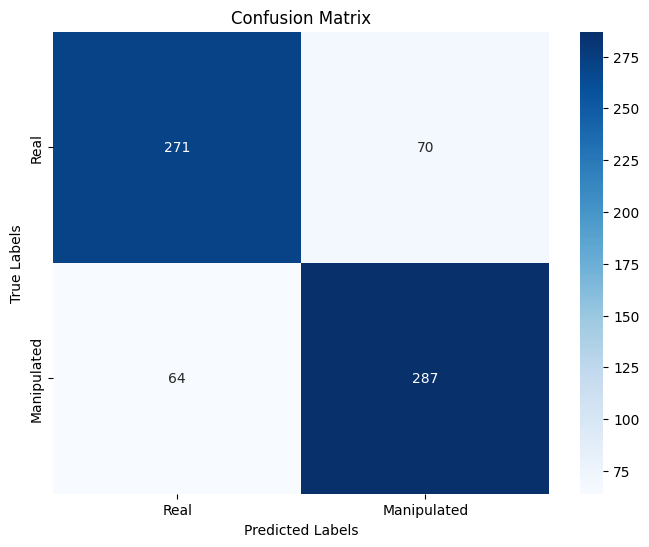

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Manipulated'], yticklabels=['Real', 'Manipulated'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()